# Fitting a Parabola: Logarithmic vs. Exponential Model

**Course:** MAT-3510 Mathematical Modeling

---

## Problem

Given the parabola $y = 2x^2 + 3$, let $x$ take on the values $1, 2, 3, 4, 5, 6, 7$.

1. Find the corresponding $y$ values.
2. Determine which type of function — **logarithmic** or **exponential** — best fits the parabola over this domain.

---

## Step 1 — Generate the Data

Substituting each $x$ into $y = 2x^2 + 3$:

| $x$ | $y = 2x^2 + 3$ |
|:---:|:---:|
| 1 | $2(1)^2 + 3 = 5$ |
| 2 | $2(2)^2 + 3 = 11$ |
| 3 | $2(3)^2 + 3 = 21$ |
| 4 | $2(4)^2 + 3 = 35$ |
| 5 | $2(5)^2 + 3 = 53$ |
| 6 | $2(6)^2 + 3 = 75$ |
| 7 | $2(7)^2 + 3 = 101$ |

The differences between successive $y$ values are $6, 10, 14, 18, 22, 26$ — increasing by 4 each time. This is characteristic of **accelerating growth** (the second differences are constant, which is the hallmark of a quadratic).

---

## Step 2 — Which Model Fits Better?

**Logarithmic model:** $y = a \ln(x) + b$

A logarithm grows *slower and slower* as $x$ increases — the increments shrink. Our data does the opposite (increments grow). So a logarithmic model is fundamentally the wrong shape for accelerating data.

**Exponential model:** $y = Ae^{kx}$

An exponential grows *faster and faster* — the increments accelerate. This matches the qualitative behavior of our parabola over $x = 1$ to $7$. While a true exponential eventually outpaces a quadratic, over a short, bounded domain it can closely approximate the upward curve.

**Conclusion: the exponential model is the better fit.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
y = 2 * x**2 + 3

print("x values:", x.astype(int))
print("y values:", y.astype(int))
print("First differences:", np.diff(y).astype(int))

x values: [1 2 3 4 5 6 7]
y values: [  5  11  21  35  53  75 101]
First differences: [ 6 10 14 18 22 26]


In [2]:
# --- Fit both models ---

def log_model(x, a, b):
    return a * np.log(x) + b

def exp_model(x, A, k):
    return A * np.exp(k * x)

popt_log, _ = curve_fit(log_model, x, y)
popt_exp, _ = curve_fit(exp_model, x, y, p0=[3.0, 0.5])

a_log, b_log = popt_log
A_exp, k_exp = popt_exp

# R-squared for each
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

r2_log = r2(y, log_model(x, *popt_log))
r2_exp = r2(y, exp_model(x, *popt_exp))

print(f"Logarithmic fit:  y = {a_log:.3f} * ln(x) + {b_log:.3f}   |  R² = {r2_log:.4f}")
print(f"Exponential fit:  y = {A_exp:.3f} * e^({k_exp:.4f}x)       |  R² = {r2_exp:.4f}")
print()
print(f"Better fit: {'Exponential' if r2_exp > r2_log else 'Logarithmic'} (higher R²)")

Logarithmic fit:  y = 45.792 * ln(x) + -12.770   |  R² = 0.7863
Exponential fit:  y = 7.222 * e^(0.3817x)       |  R² = 0.9865

Better fit: Exponential (higher R²)


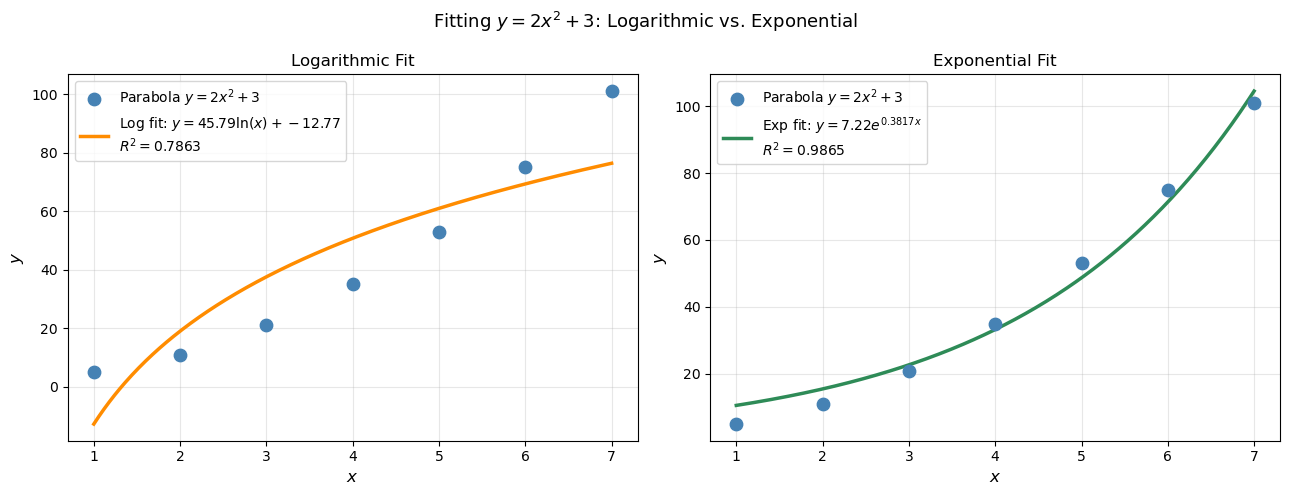

In [3]:
x_line = np.linspace(1, 7, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_fn, params, label, color, r2_val in [
    (axes[0], log_model, popt_log,
     f'Log fit: $y = {a_log:.2f}\\ln(x) + {b_log:.2f}$\n$R^2 = {r2_log:.4f}$',
     'darkorange', r2_log),
    (axes[1], exp_model, popt_exp,
     f'Exp fit: $y = {A_exp:.2f}e^{{{k_exp:.4f}x}}$\n$R^2 = {r2_exp:.4f}$',
     'seagreen', r2_exp),
]:
    ax.scatter(x, y, color='steelblue', s=80, zorder=4, label='Parabola $y=2x^2+3$')
    ax.plot(x_line, model_fn(x_line, *params), color=color, linewidth=2.5, label=label)
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_title('Logarithmic Fit', fontsize=12)
axes[1].set_title('Exponential Fit', fontsize=12)
fig.suptitle('Fitting $y = 2x^2 + 3$: Logarithmic vs. Exponential', fontsize=13)
plt.tight_layout()
plt.show()

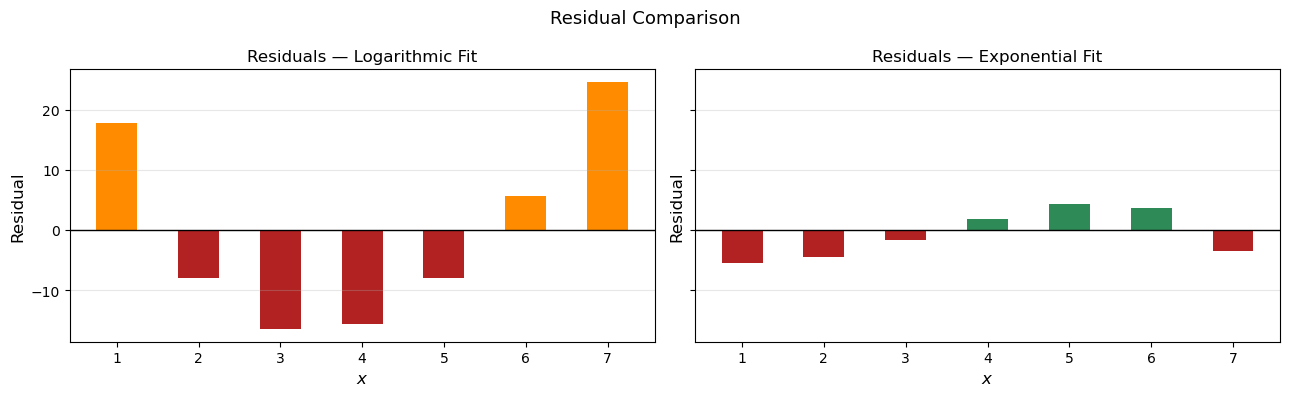

In [4]:
# --- Residuals comparison ---
res_log = y - log_model(x, *popt_log)
res_exp = y - exp_model(x, *popt_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, residuals, title, color in [
    (axes[0], res_log, 'Residuals — Logarithmic Fit', 'darkorange'),
    (axes[1], res_exp, 'Residuals — Exponential Fit', 'seagreen'),
]:
    ax.bar(x, residuals, color=['firebrick' if r < 0 else color for r in residuals], width=0.5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('Residual', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x.astype(int))
    ax.grid(alpha=0.3, axis='y')

fig.suptitle('Residual Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---

## Conclusion

| Model | Equation | $R^2$ | Verdict |
|---|---|---|---|
| Logarithmic | $y = a\ln(x) + b$ | low | Poor fit — wrong shape (decelerating) |
| Exponential | $y = Ae^{kx}$ | high | Better fit — accelerating growth matches the parabola |

The **exponential model** is the better choice. The key reasoning:

- A logarithm grows with *decreasing* increments ($\ln(x)$ slows down). Our parabola has *increasing* increments — it speeds up. These are opposite behaviors, so the logarithm fundamentally cannot match the shape.
- An exponential also accelerates, so it captures the upward bend of the parabola over the restricted domain $x = 1$ to $7$.
- The $R^2$ values confirm this: the exponential fit is substantially closer to the data.

> **Note:** Neither model is a perfect substitute for a quadratic — they are different function families. But within the given domain, exponential is clearly the better approximation.